In [1]:
from src import systemClasses, baseClasses, sensorClasses
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import warnings
import pickle
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
dataset = baseClasses.Data()
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 15))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 20)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [12]:
class Calibration():
    def __init__(self, dataset, tini, tend, is_mux_equalized=True):
        self.is_mux_equalized = is_mux_equalized
        self.dataset = dataset
        self.tini = tini
        self.tend = tend
        self._info()
        self._data()

    def _info(self):
        logFile = baseClasses.LogFile().configurations
        logFile["Start"] = pd.to_datetime(logFile["Start"])
        logFile["End"] = pd.to_datetime(logFile["End"])
        logFile = logFile.loc[(logFile["Start"] <= self.tend) & (logFile["End"] >= self.tini)]
        if len(logFile) == 0:
            self.configurations = None
            print(f"ERROR: No configurations found for the selected time range")
        else:
            self.configurations = logFile
            self.systems = {}
            for index, configurationRow in self.configurations.iterrows():
                mapping = baseClasses.Configuration(configurationRow["Configuration"]).mapping
                # hp_systems = mapping.loc[(mapping["BOARD"]<=4)]["SYSTEM"].unique()
                hp_systems = mapping["SYSTEM"].unique()
                self.systems[configurationRow["Configuration"]] = {"tini": configurationRow["Start"], "tend": configurationRow["End"], "systems": hp_systems}
            if len(self.systems) == 0:
                self.systems = None
                print(f"ERROR: No systems found for the selected time range")
        return self

    def _data(self):
        if self.systems is not None:
            self.sensors = {}
            cnt = 0
            print(f"Found {len(self.systems)} configurations with HP systems in the selected time range:")
            if len(self.systems) == 0:
                print(f"ERROR: No configurations found with HP systems in the selected time range")
                return self
            print(f"Configurations found: {list(self.systems.keys())}")
            print(f"Collecting data for the configurations...")
            for configuration, info in self.systems.items():
                print(f"Collecting data for configuration '{configuration}' between {info['tini']} and {info['tend']}")
                self.sensors[cnt] = {"configuration": configuration, "tini": max([info["tini"], self.tini]), "tend": min([info["tend"], self.tend]), "sensors": {}}
                for systemName in info["systems"]:
                    if systemName not in ["TGRAD", "HAWAI", "PRM", "PIPE", "PP", "APA", "GA1", "GA2", "WALL", "FLOOR"]:
                        continue
                    print(f"  - System: {systemName}")
                    system = systemClasses.System(self.dataset, systemName)
                    if self.is_mux_equalized:
                        system.muxEqualization()
                    else:
                        pass
                    for id, sensor in system.sensors.items():
                        if sensor not in self.sensors[cnt]["sensors"]:
                            self.sensors[cnt]["sensors"][id] = sensor
                        else:
                            self.sensors[cnt]["sensors"][id] = sensor
                            print(f"WARNING: Sensor {sensor} already exists in the configuration {configuration} between {info['tini']} and {info['tend']}")
                cnt += 1
        return self

    def calibrate(self, ref=40525):
        if self.sensors is not None:
            self.calib = {}
            for cnt, sensors in self.sensors.items():
                self.calib[cnt] = {"configuration": sensors["configuration"], "tini": sensors["tini"], "tend": sensors["tend"], "ref":ref, "calib": {}}
                if ref not in sensors["sensors"].keys():
                    print(f"ERROR: Reference sensor {ref} not found in the configuration {sensors['configuration']} between {sensors['tini']} and {sensors['tend']}")
                    continue
                if sensors["sensors"][ref] is None:
                    print(f"ERROR: Reference sensor {ref} is None in the configuration {sensors['configuration']} between {sensors['tini']} and {sensors['tend']}")
                    continue
                ref_sensor = sensors["sensors"][ref]
                for id, sensor in sensors["sensors"].items():
                    if sensor is not None:
                        cc = (
                            sensor.data.loc[(sensor.data.index >= sensors["tini"]) & (sensor.data.index <= sensors["tend"]) & (sensor.data>0) & (sensor.data<90)] -
                            ref_sensor.data.loc[(ref_sensor.data.index >= sensors["tini"]) & (ref_sensor.data.index <= sensors["tend"]) & (ref_sensor.data>0) & (ref_sensor.data<90)]
                            ).dropna().mean()
                        err = (
                            sensor.data.loc[(sensor.data.index >= sensors["tini"]) & (sensor.data.index <= sensors["tend"]) & (sensor.data>0) & (sensor.data<90)] -
                            ref_sensor.data.loc[(ref_sensor.data.index >= sensors["tini"]) & (ref_sensor.data.index <= sensors["tend"]) & (ref_sensor.data>0) & (ref_sensor.data<90)]
                            ).dropna().std()
                        if pd.isna(cc) or pd.isna(err):
                            cc, err = 0, 0
                        self.calib[cnt]["calib"][str(id)] = {"cc": 1e3*cc, "cc_err": 1e3*err}
                self.calib[cnt]["calib"] = pd.DataFrame(self.calib[cnt]["calib"]).T
        return self

In [4]:
sensor1 = sensorClasses.Sensor(dataset=dataset, id=39646)

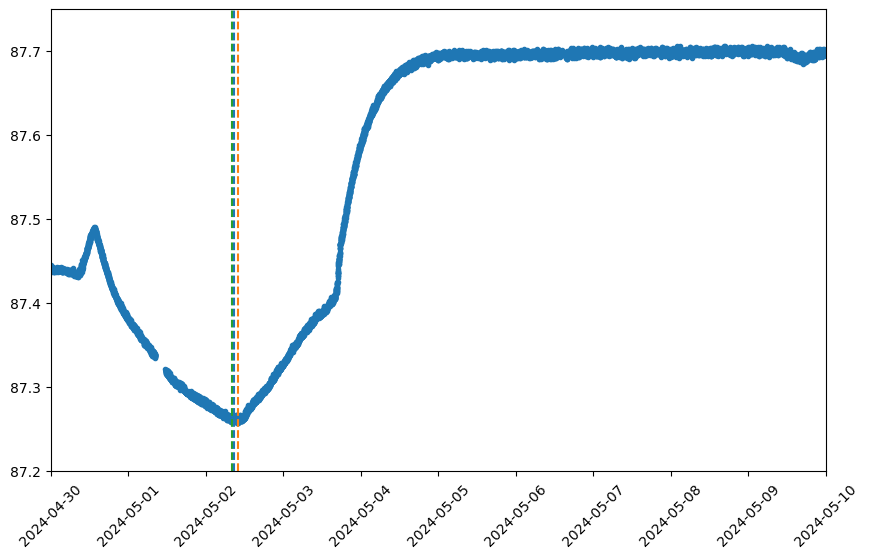

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
axes.plot(sensor1.data.index, sensor1.data.values, ".", label="Sensor 39646")
axes.set_xlim(pd.Timestamp("2024-4-30"), pd.Timestamp("2024-5-10"))
axes.set_ylim(87.2, 87.75)
axes.tick_params(axis='x', rotation=45)

t1 = datetime.datetime(2024, 5, 2, 10, 8, 0)
t2 = datetime.datetime(2024, 5, 2, 8, 15, 0)
t3 = datetime.datetime(2024, 5, 2, 8, 41, 0)
axes.axvline(t2, color="tab:green", linestyle="--", label="POFF(CE OFF)-PRECISION")
axes.axvline(t1, color="tab:orange", linestyle="--", label="POFF-PIPES")
axes.axvline(t3, color="tab:blue", linestyle="--", label="POFF(CE OFF)-PUMPS")


In [13]:
cal_pumps = Calibration(dataset, datetime.datetime(2024, 5, 2, 8, 41, 0), datetime.datetime(2024, 5, 2, 8, 46, 0), is_mux_equalized=True)
cal_pumps.calibrate()
print(cal_pumps.calib[0]["calib"])
with open('/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-05-02_084100_2024-05-02_084600.pkl', 'wb') as f:
    pickle.dump({"40525":cal_pumps.calib[0]["calib"]}, f)

Found 1 configurations with HP systems in the selected time range:
Configurations found: ['pumps']
  - System: TGRAD


Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.63sensor/s]


  - System: PP


Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  8.71sensor/s]


...

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.01sensor/s]


ERROR: Channel (TE0120) not found
  - System: APA


Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 13.49sensor/s]


                cc    cc_err
39666   -44.198381  3.396679
39665   -30.834717  3.314330
39664    -4.806594  2.482683
39667    -1.091481  2.679100
39661   -20.171392  2.350261
...            ...       ...
44113  -422.391917  2.394119
49991 -1199.259279  1.902339
44115  -369.575154  2.090292
44114  -392.243187  3.266854
49992 -1523.217320  2.239907

[84 rows x 2 columns]


In [93]:
cal_pipes = Calibration(dataset, datetime.datetime(2024, 5, 2, 10, 0, 0), datetime.datetime(2024, 5, 2, 10, 9, 0), is_mux_equalized=True)
cal_pipes.calibrate()
print(cal_pipes.calib[0]["calib"])
with open('/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-05-02_100000_2024-05-02_100900.pkl', 'wb') as f:
    pickle.dump({"40525":cal_pipes.calib[0]["calib"]}, f)

Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.76sensor/s]


ERROR: System (nan) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.15sensor/s]


ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.31sensor/s]


ERROR: Channel (TE0120) not found
                cc    cc_err
39666   -48.854123  4.041261
39665   -33.282447  2.914614
39664    -5.107258  3.443829
39667     0.155684  4.162577
39661   -20.040510  3.754489
39660   -21.357780  3.348712
39655   -48.367069  3.017452
39654   -47.273533  3.321299
39653   -73.964189  3.566784
39652   -43.567623  2.514958
99999   -29.880355  2.204079
39651    -3.489643  1.642777
39650   -29.042641  1.199465
40526   -17.782328  0.922841
40525     0.000000  0.000000
40524   -45.697867  1.059096
39659   -60.135302  0.971188
39658   -43.089506  1.088671
39657   -35.751550  2.136724
39649   -39.513370  2.067382
39648   -53.995180  1.895187
39647   -64.773871  1.759630
39646   -50.629958  1.995841
39644   -50.567130  1.644554
39630   -58.258060  2.134205
39629    -1.342992  2.082919
39628   -43.167690  1.909444
39627   -15.854930  2.010007
39626   -10.331227  1.990918
39625   -29.160360  2.472919
39624   -56.565565  2.340643
39623   -31.780042  2.360470
39622   -

In [94]:
cal_precision = Calibration(dataset, datetime.datetime(2024, 5, 2, 8, 5, 0), datetime.datetime(2024, 5, 2, 8, 15, 0), is_mux_equalized=True)
cal_precision.calibrate()
print(cal_precision.calib[0]["calib"])
with open('/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-05-02_080500_2024-05-02_081500.pkl', 'wb') as f:
    pickle.dump({"40525":cal_precision.calib[0]["calib"]}, f)

Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.73sensor/s]


ERROR: System (nan) not found
                cc     cc_err
39666   -49.610945   3.046065
39665   -33.796485   2.561655
39664    -5.398751   2.097648
39667    -1.913838   2.399182
39661   -21.632268   2.563212
39660   -23.279258   2.770799
39655   -50.687910   2.999262
39654   -49.119814   2.242729
39653   -75.331649   1.656188
39652   -42.884840   2.850527
99999   -29.347262   2.260625
39651    -3.092391   2.041555
39650   -28.369898   1.398274
40526   -17.306078   1.284706
40525     0.000000   0.000000
40524   -45.986175   0.996676
39659   -60.314115   1.240490
39658   -43.949854   1.480457
39657   -35.300391   1.712648
39649   -38.507603   1.998449
39648   -53.781727   1.721447
39647   -65.870960   1.566172
39646   -52.987238   1.681637
39644   -52.037830   1.924977
39630   -60.353267   1.640062
39629    -3.097427   1.827515
39628   -46.391419   1.694667
39627   -18.386029   2.018988
39626   -12.958922   2.111467
39625   -31.879839   2.703923
39624   -59.486758   2.126181
39623   -3

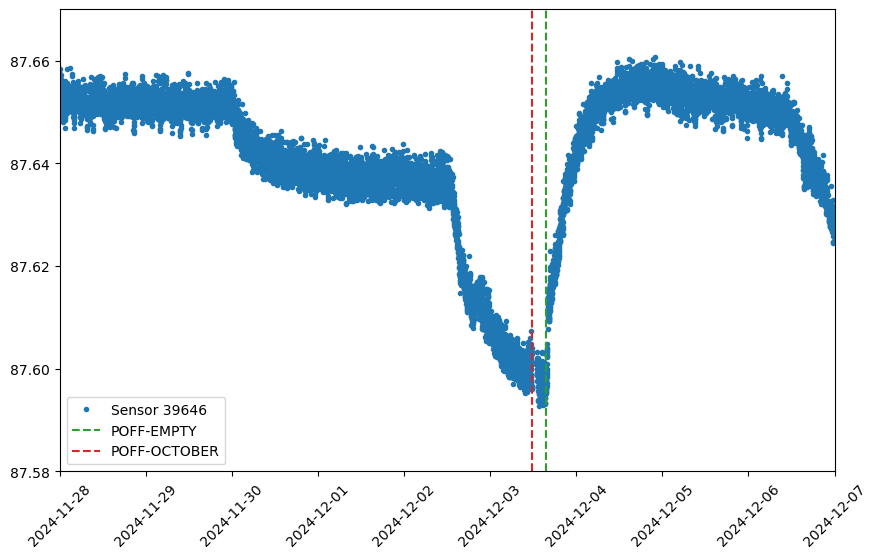

In [103]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
axes.plot(sensor1.data.index, sensor1.data.values, ".", label="Sensor 39646")
axes.set_xlim(pd.Timestamp("2024-11-28"), pd.Timestamp("2024-12-7"))
axes.set_ylim(87.58, 87.67)
axes.tick_params(axis='x', rotation=45)

t1 = datetime.datetime(2024, 12, 3, 15, 35, 0)
t2 = datetime.datetime(2024, 12, 3, 11, 45, 0)
axes.axvline(t1, color="tab:green", linestyle="--", label="POFF-EMPTY")
axes.axvline(t2, color="tab:red", linestyle="--", label="POFF-OCTOBER")
axes.legend()


In [96]:
cal_empty = Calibration(dataset, datetime.datetime(2024, 12, 3, 15, 25, 0), datetime.datetime(2024, 12, 3, 15, 35, 0), is_mux_equalized=True)
cal_empty.calibrate()
print(cal_empty.calib[0]["calib"])
with open('/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-12-03_153500_2024-12-03_153500.pkl', 'wb') as f:
    pickle.dump({"40525":cal_empty.calib[0]["calib"]}, f)

Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.52sensor/s]


ERROR: System (nan) not found
                cc     cc_err
39666   -40.211005  11.318579
39665   -25.112600   3.953520
39664    -7.786427   2.111921
39667    -1.743036   2.128931
39661   -21.918378   1.869773
39660   -23.068807   2.148772
39655   -43.309220   1.826196
39654   -48.617517   1.463030
39653   -74.111861   1.273256
39652   -42.228373   1.382122
99999   -28.303161   1.145191
39651    -3.035985   0.746701
39650   -27.435993   0.785049
40526   -16.841685   0.394898
40525     0.000000   0.000000
40524   -42.702399   0.592567
39659   -57.935337   0.568144
39658   -46.050806   0.685475
39657   -32.583121   1.052599
39649   -36.301434   1.289061
39648   -52.539667   1.351074
39647   -64.529485   1.676651
39646   -49.911242   1.783963
39644   -51.443326   1.905977
39630   -55.022799   2.106759
39629     3.100930   1.975815
39628   -42.529681   1.698247
39627   -13.732041   1.353075
39626    -8.726111   1.417599
39625   -33.252733   1.724255
39624   -53.421458   1.853351
39623   -3

In [97]:
cal_october = Calibration(dataset, datetime.datetime(2024, 12, 3, 11, 35, 0), datetime.datetime(2024, 12, 3, 11, 45, 0), is_mux_equalized=True)
cal_october.calibrate()
print(cal_october.calib[0]["calib"])
with open('/Users/jcapo/cernbox/RTDdata/calib/all/poff_2024-12-03_113500_2024-12-03_114500.pkl', 'wb') as f:
    pickle.dump({"40525":cal_october.calib[0]["calib"]}, f)

Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.60sensor/s]


ERROR: System (nan) not found


Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  8.39sensor/s]


ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.41sensor/s]


ERROR: Channel (TE0120) not found
                cc    cc_err
39666   -45.444547  6.956555
39665   -25.103169  6.537487
39664    -2.913326  4.327692
39667     2.288595  3.219356
39661   -18.827861  3.123734
39660   -19.375404  4.278302
39655   -40.740708  4.726509
39654   -46.468701  4.825938
39653   -72.828204  5.489929
39652   -43.019584  4.948741
99999   -29.288291  4.088483
39651    -3.236439  4.035636
39650   -28.450774  2.661853
40526   -15.990023  2.982510
40525     0.000000  0.000000
40524   -45.069355  1.355757
39659   -59.136708  2.098459
39658   -44.830812  2.123496
39657   -33.753180  1.953827
39649   -38.684290  2.510949
39648   -53.016605  2.552614
39647   -63.903923  2.323847
39646   -49.475115  2.587372
39644   -50.983166  3.220782
39630   -55.092284  3.027043
39629     1.034239  3.799853
39628   -44.461892  3.482569
39627   -15.961138  3.665412
39626   -10.143942  3.080974
39625   -33.940316  3.507622
39624   -55.908395  3.449415
39623   -32.461905  3.793119
39622   -

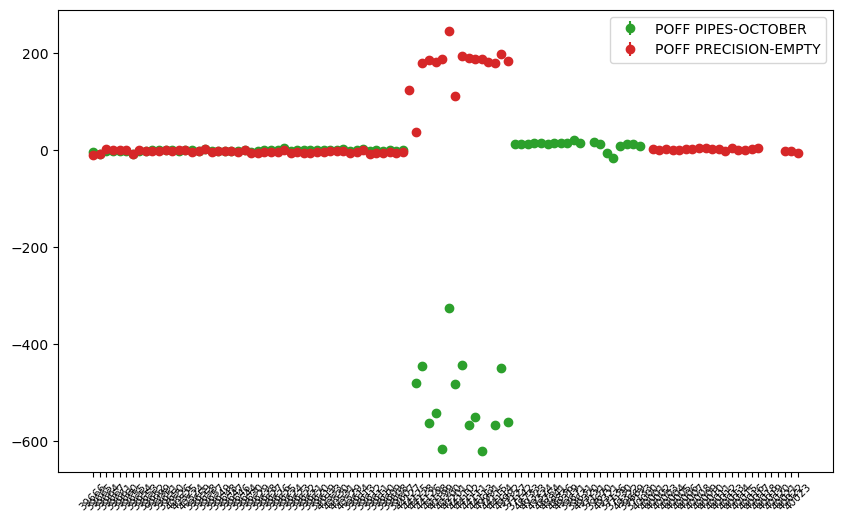

In [98]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
axes.errorbar(
    (cal_pipes.calib[0]["calib"] - cal_october.calib[0]["calib"]).index,
    (cal_pipes.calib[0]["calib"] - cal_october.calib[0]["calib"])["cc"],
    yerr=(cal_pipes.calib[0]["calib"] - cal_october.calib[0]["calib"])["cc_err"],
    fmt="o",
    label="POFF PIPES-OCTOBER",
    color="tab:green"
)

axes.errorbar(
    (cal_precision.calib[0]["calib"] - cal_empty.calib[0]["calib"]).index,
    (cal_precision.calib[0]["calib"] - cal_empty.calib[0]["calib"])["cc"],
    yerr=(cal_precision.calib[0]["calib"] - cal_empty.calib[0]["calib"])["cc_err"],
    fmt="o",
    label="POFF PRECISION-EMPTY",
    color="tab:red"
)

axes.tick_params(axis='x', rotation=45, labelsize=7.5)
axes.legend()